# Finding other important rates

In [1]:
import pynucastro as pyna
import mesa_reader as mr

In [2]:
from pynucastro import mesa_utils
from pynucastro.screening import chugunov_2007

## Read in the MESA model

In [3]:
model = mr.MesaData("profile2.data")

In [4]:
nuclei = mesa_utils.get_nuclei(model)

In [5]:
mesa_zones = mesa_utils.get_all_data(model)

## Create the network using the same species as the MESA model

By default, `network_helper` will find all the rates connecting the nuclei, some of which were likely not used in the MESA simulation.

In [6]:
net = pyna.network_helper(nuclei)

In [7]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 15
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 38

  rates explicitly connecting nuclei: 38
  hidden rates: 0

  reaclib rates: 12
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 14
  approximate rates: 0
  derived rates: 12
  modified rates: 0
  custom rates: 0


We can see the structure of the network

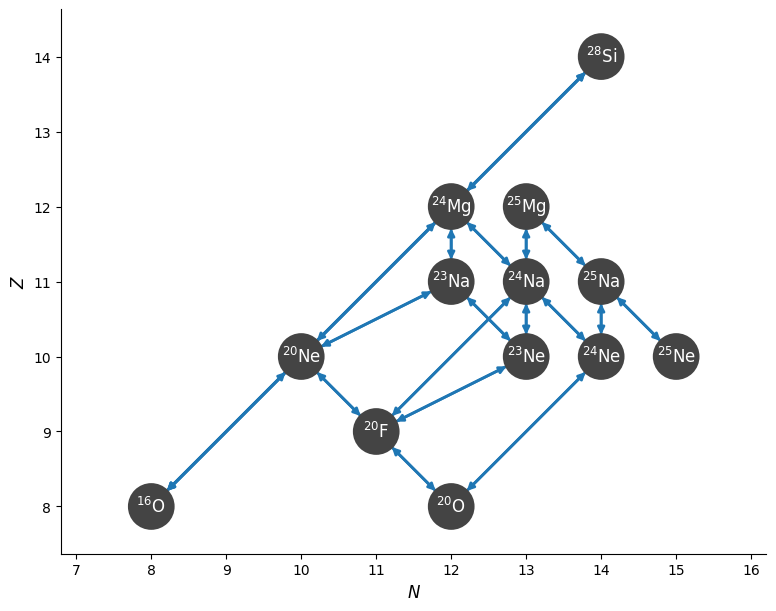

In [8]:
fig = net.plot()

## Check nuclei for other branches

In [9]:
full_library = pyna.full_library()

In [10]:
_, missing_rates = net.validate(full_library, return_dict=True)

validation: Si28 produced in O16 + O16 ⟶ He4 + Si28 never consumed.
validation: Si28 produced in Mg24 + He4 ⟶ Si28 + 𝛾 never consumed.


In [11]:
len(missing_rates)

46

In [12]:
lib = pyna.Library(rates=list(missing_rates.keys()))

In [13]:
lib

O16 + O16 ⟶ p + P31            [Q =   7.68 MeV] (O16 + O16 --> p + P31 <reaclib_cf88>)
O16 + O16 ⟶ n + S31            [Q =   1.50 MeV] (O16 + O16 --> n + S31 <reaclib_cf88>)
O20 + He4 ⟶ n + Ne23           [Q =   3.30 MeV] (O20 + He4 --> n + Ne23 <reaclib_rpsm>)
F20 + He4 ⟶ n + Na23           [Q =   3.87 MeV] (F20 + He4 --> n + Na23 <reaclib_rpsm>)
Ne23 + p ⟶ n + Na23            [Q =   3.59 MeV] (Ne23 + p --> n + Na23 <reaclib_rath>)
Ne24 + p ⟶ n + Na24            [Q =   1.69 MeV] (Ne24 + p --> n + Na24 <reaclib_rath>)
Na24 + p ⟶ He4 + Ne21          [Q =   2.18 MeV] (Na24 + p --> He4 + Ne21 <reaclib_rath>)
Na24 + p ⟶ n + Mg24            [Q =   4.73 MeV] (Na24 + p --> n + Mg24 <reaclib_rath>)
O16 + He4 ⟶ p + F19            [Q =  -8.11 MeV] (O16 + He4 --> p + F19 <reaclib_nacr>)
O16 + He4 ⟶ n + Ne19           [Q = -12.13 MeV] (O16 + He4 --> n + Ne19 <reaclib_ths8>)
O20 + He4 ⟶ p + F23            [Q =  -4.40 MeV] (O20 + He4 --> p + F23 <reaclib_rpsm>)
O20 ⟶ n + O19                  [Q =  -

In [14]:
all_rates = net.get_rates() + list(missing_rates.keys())

In [15]:
from pynucastro.rates.known_duplicates import find_duplicate_rates

In [16]:
rr = find_duplicate_rates(all_rates)

In [17]:
r0, r1 = rr[0]

IndexError: list index out of range

In [ ]:
r0

In [ ]:
r1

In [ ]:
r0.products == r1.products